In [50]:
import os 

IMAGE_DIR = "../NBA Logos"
image_files = os.listdir(IMAGE_DIR)

In [ ]:
logo_dict = {}

for image_file in sorted(image_files):
    city, nickname, tenure = image_file.rsplit("_", maxsplit=2)
    try:
        start, end = tenure[:-4].split("-")
    except:
        start = tenure[:-4]
        end = tenure[:-4]
    city = city.replace("_", " ").title()
    nickname = nickname.title() if nickname != "76ers" else nickname
    end = end if end != "pres" else "2026"

    start, end = int(start), min(int(end), 2026)

    if city + " " + nickname not in logo_dict:
        logo_dict[city + " " + nickname] = {}
    print(f"Adding {city + " " + nickname} for years {start}-{end}")
    for year in range(start, end + 1):
        logo_dict[city + " " + nickname][year] = image_file


Adding Anderson Packers for years 1950-1950
Adding Atlanta Hawks for years 1969-1969
Adding Atlanta Hawks for years 1970-1970
Adding Atlanta Hawks for years 1971-1972
Adding Atlanta Hawks for years 1973-1995
Adding Atlanta Hawks for years 1996-2007
Adding Atlanta Hawks for years 2008-2014
Adding Atlanta Hawks for years 2015-2020
Adding Atlanta Hawks for years 2021-2026
Adding Baltimore Bullets for years 1963-1967
Adding Baltimore Bullets for years 1968-1968
Adding Baltimore Bullets for years 1969-1969
Adding Baltimore Bullets for years 1970-1970
Adding Baltimore Bullets for years 1971-1972
Adding Boston Celtics for years 1947-1950
Adding Boston Celtics for years 1951-1964
Adding Boston Celtics for years 1965-1966
Adding Boston Celtics for years 1967-1969
Adding Boston Celtics for years 1970-1996
Adding Boston Celtics for years 1997-2026
Adding Brooklyn Nets for years 2013-2024
Adding Brooklyn Nets for years 2025-2026
Adding Buffalo Braves for years 1971-1971
Adding Buffalo Braves for y

In [58]:
import pandas as pd 

BASE_LOGO_URL = "https://cdn.jsdelivr.net/gh/smileytr25/NBA-Logos@master/NBA%20Logos/"

logo_data = []
for team, year_dict in logo_dict.items():
    for year, url in year_dict.items():
        logo_data.append([team, year, BASE_LOGO_URL + url])

logo_df = pd.DataFrame(logo_data, columns=["team", "season", "image_url"])

In [60]:
from sqlalchemy import create_engine
from pathlib import Path 

db_path = Path("~/Personal Project/data/nba.db").expanduser()
engine = create_engine(f"sqlite:///{db_path}")

logo_df.to_sql(
    "team_logo_history",
    engine,
    if_exists="replace",
    index=False
)


1747

https://cdn.jsdelivr.net/gh/smileytr25/NBA-Logos@master/NBA%20Logos/detroit_pistons_2002-2005.png


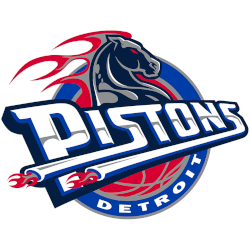

In [64]:
from sqlalchemy import text
from PIL import Image
from io import BytesIO
import requests

conn = engine.connect()

result = conn.execute(
    text("""
        SELECT image_url
        FROM team_logo_history
        WHERE team = :team
          AND season = :season
        LIMIT 1
    """),
    {"team": "Detroit Pistons", "season": 2002}
)

row = result.fetchone()

if row is None:
    print("No logo found")
else:
    image_url = row[0]
    print(image_url)

    response = requests.get(image_url)
    response.raise_for_status()

    img = Image.open(BytesIO(response.content))
    display(img)